# 01 — Explore the CARD data

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jean-jsj/CARD/blob/main/examples/01_explore_data.ipynb)

CARD (Causal Recovery of Demand) asks one question: **can a model that forecasts
retail sales well also predict what happens when a price changes?** The two skills
diverge because the simulated retailer discounts more deeply exactly where hidden
demand is strongest, so price and sales are correlated for a reason that is not
the causal effect of price. The benchmark ships synthetic scanner panels whose
true elasticities and counterfactual outcomes are known — and withheld for
scoring.

This notebook walks through everything a participant sees in one benchmark cell:
the transaction panel, the product table with its marketing copy, the store
table, the two instruments, and the counterfactual scenarios you are scored on.

It runs on the **mini slice** (10 stores instead of 731, ~18 MB instead of ~1 GB) so
every cell executes in seconds. Everything transfers 1:1 to the full cells.

- Repo and docs: https://github.com/jean-jsj/CARD
- Data: https://huggingface.co/datasets/jean-jsj/CARD

In [1]:
# Setup: works from a local clone or on Colab (clones the repo, no pip install needed).
import os, subprocess, sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("metrics").is_dir():
    subprocess.run(["git", "clone", "-q", "https://github.com/jean-jsj/CARD"], check=True)
    os.chdir("CARD")
elif Path.cwd().name == "examples":
    os.chdir("..")
assert Path("metrics").is_dir(), "run this notebook from the CARD repo root or on Colab"
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 11, "font.size": 10})
BLUE, GREEN, GRAY = "#2a78d6", "#008300", "#6b7280"

In [2]:
# Fetch the ~18 MB starter slice of the endogeneity-on cell (10 stores, all 40 products).
from huggingface_hub import snapshot_download

CELL = "complex_log_log_endogenous_seed001"
cell_dir = Path("benchmark/dev_mini") / CELL
if not cell_dir.exists():
    snapshot_download(repo_id="jean-jsj/CARD", repo_type="dataset",
                      allow_patterns=[f"dev_mini/{CELL}/*"], local_dir="benchmark")
print("data at:", cell_dir)

data at: benchmark/dev_mini/complex_log_log_endogenous_seed001


## The files of a cell

Each cell directory has a `public/` half (everything your model may consume) and a
`hidden/` half (**dev seed only**: the scoring truth, so you can score locally —
never model input). See [docs/DATA.md](../docs/DATA.md) for the column-by-column
data dictionary.

In [3]:
public = cell_dir / "public"
train    = pd.read_csv(public / "transactions_train_public.csv")
holdout  = pd.read_csv(public / "transactions_holdout_context_public.csv")
sweep    = pd.read_csv(public / "counterfactual_sweep_context_public.csv")
products = pd.read_csv(public / "products_public.csv")
stores   = pd.read_csv(public / "stores_public.csv")

for name, df in [("train", train), ("holdout context", holdout), ("sweep context", sweep),
                 ("products", products), ("stores", stores)]:
    print(f"{name:16s} {df.shape[0]:>9,} rows x {df.shape[1]} cols")

train               36,569 rows x 9 cols
holdout context      4,576 rows x 7 cols
sweep context       73,216 rows x 7 cols
products                40 rows x 3 cols
stores                  10 rows x 3 cols


## The transaction panel

One row per product x store x week **with positive sales** — the panel is a
positive-sales extract in the style of a raw scanner file, so a store's assortment
must be inferred from the rows that appear. The training window is the first 140
weeks; the final 16 weeks are withheld for forecast scoring.

In [4]:
train.head()

,product_id,store_id,week,units,dollars,price,promo_flag,promo_cost,supply_cost_proxy
0,P001,S0001,1427,287.0,513.73,1.79,0,0.0,1.0069
1,P002,S0001,1427,26.0,28.34,1.09,0,0.0,0.6072
2,P003,S0001,1427,91.0,181.09,1.99,0,0.0,1.0279
3,P004,S0001,1427,59.0,99.71,1.69,0,0.0,1.0241
4,P005,S0001,1427,10.0,23.90,2.39,0,0.0,1.2248


In [5]:
print(f"weeks {train.week.min()}..{train.week.max()} "
      f"({train.week.nunique()} training weeks; the last 16 weeks are the holdout)")
print(f"{train.product_id.nunique()} products, {train.store_id.nunique()} stores (mini slice)")

# Assortment: which products does each store actually carry?
carried = train.groupby("store_id")["product_id"].nunique()
print(f"products carried per store: min {carried.min()}, median {int(carried.median())}, max {carried.max()}")

weeks 1427..1566 (140 training weeks; the last 16 weeks are the holdout)
40 products, 10 stores (mini slice)
products carried per store: min 19, median 28, max 35


## Prices and promotions

Shelf prices are sticky (they reset only about twice a year, at the chain level)
and promotions are multi-week discount spells. Below: the flagship product — the
highest-share product, whose +10% price scenario carries the benchmark headline —
in one store. Promotion weeks are shaded.

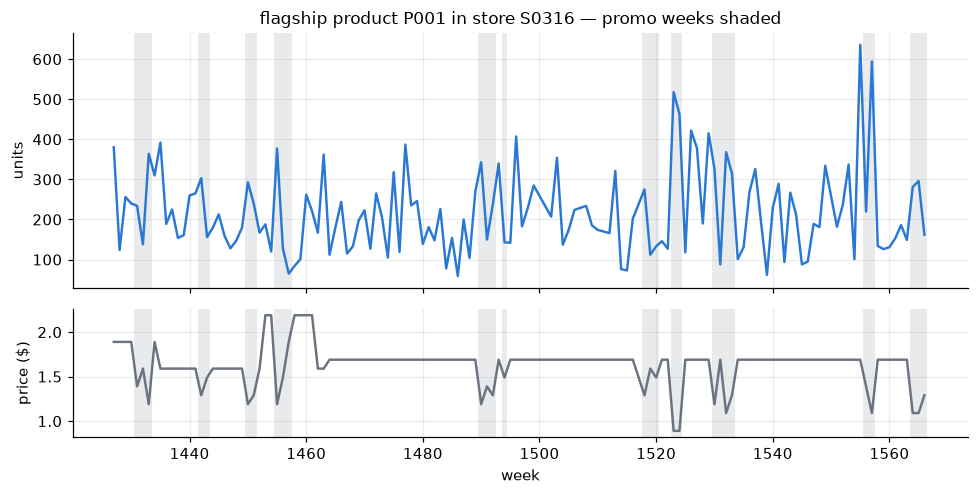

In [6]:
# The flagship is the product whose price the headline scenario moves.
flag_rows = sweep[sweep.intervention_id == "sweep_single_share_highest_plus10"]
flagship = flag_rows.loc[flag_rows.baseline_price != flag_rows.intervention_price, "product_id"].iloc[0]
store = train[train.product_id == flagship].groupby("store_id")["units"].sum().idxmax()
one = train[(train.product_id == flagship) & (train.store_id == store)].sort_values("week")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
for ax in (ax1, ax2):
    for w in one.loc[one.promo_flag == 1, "week"]:
        ax.axvspan(w - 0.5, w + 0.5, color=GRAY, alpha=0.15, lw=0)
ax1.plot(one.week, one.units, color=BLUE, lw=1.6)
ax1.set_ylabel("units")
ax1.set_title(f"flagship product {flagship} in store {store} — promo weeks shaded")
ax2.plot(one.week, one.price, color=GRAY, lw=1.6)
ax2.set_ylabel("price ($)")
ax2.set_xlabel("week")
plt.tight_layout()
plt.show()

Sales spike in exactly the weeks price dips. The benchmark's question is how much
of that spike is *caused by* the price cut — in the endogeneity-on cells, part of
it is the hidden demand that triggered the discount in the first place.

## The product text

Each product ships with three sentences of marketing copy. The copy is not
decoration: the substitution structure — which products compete closely — is
carried in the *meaning* of the text, and the transactions alone carry only a
weak trace of it. Any method is free to ignore the text, but text-aware reference
models approach the ceiling on substitution recovery and text-blind ones do not.

In [7]:
pd.set_option("display.max_colwidth", None)
products.sample(3, random_state=0)[["product_id", "brand_code", "product_text"]]

,product_id,brand_code,product_text
22,P023,B2,"The surface is soft and smooth to the hand, gently comfortable and easygoing. Small enough for a satchel or a handbag, it rides along with ease. The feel keeps an honest softness, gentle and unfussy and evenly smooth."
20,P021,B8,"A soft and gentle touch meets the skin with a plain and smooth comfort. As a family supply it stocks the shelf and holds through the season. It keeps a soft and understated comfort, smooth and honestly gentle throughout."
25,P026,B7,"Sumptuously soft and downy, it offers a cushiony and luxurious touch. It gathers around the home, ready in the kitchen and the living room. A cloud soft and downy feel carries through, sumptuous and pampering throughout."


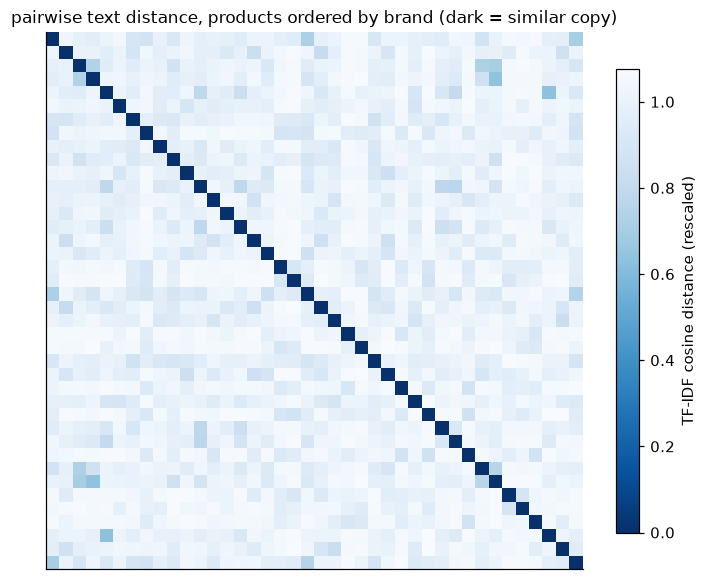

In [8]:
# A first look at the structure the text carries: TF-IDF cosine distances
# between the 40 texts (the shipped text-aware baselines start exactly here).
from baselines.text_distance import text_distance_matrix

dist = text_distance_matrix(products)
order = np.argsort(products.brand_code.to_numpy())
ids = products.product_id.to_numpy()[order]
fig, ax = plt.subplots(figsize=(6.4, 5.6))
im = ax.imshow(dist.loc[ids, ids], cmap="Blues_r", interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("pairwise text distance, products ordered by brand (dark = similar copy)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="TF-IDF cosine distance (rescaled)")
plt.tight_layout(); plt.show()

## The two instruments

Because discounts respond to hidden demand, a regression of sales on price is
confounded. The release therefore includes two cost-side columns whose validity
is guaranteed by construction:

- **`supply_cost_proxy`** (primary): the unit cost as of the store's most recent
  price reset. Shelf prices are sticky markups over cost, so it moves the everyday
  shelf price and never touches the demand shock.
- **`promo_cost`** (secondary): the random draw behind a promotion's baseline
  discount depth. It moves the final price only through the discount.

They are equally valid but **not interchangeable** — they shift different
components of the price and identify different causal quantities. Choosing the
instrument that matches the question is part of the benchmark.

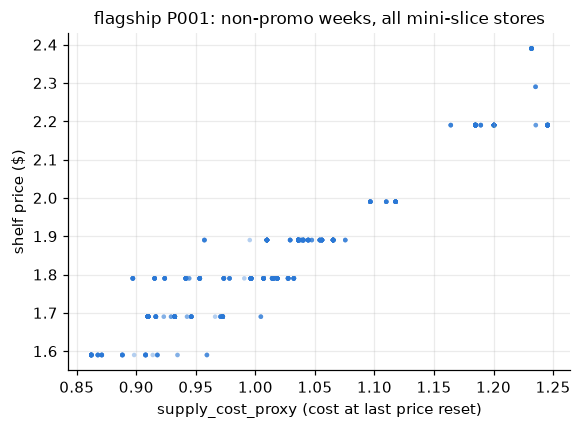

In [9]:
# The primary instrument tracks the shelf price component within a product-store.
sub = train[(train.product_id == flagship) & (train.promo_flag == 0)]
fig, ax = plt.subplots(figsize=(5.4, 4))
ax.scatter(sub.supply_cost_proxy, sub.price, s=9, alpha=0.35, color=BLUE, edgecolors="none")
ax.set_xlabel("supply_cost_proxy (cost at last price reset)")
ax.set_ylabel("shelf price ($)")
ax.set_title(f"flagship {flagship}: non-promo weeks, all mini-slice stores")
plt.tight_layout(); plt.show()

## What you are asked to predict

Three files per cell (formats in
[metrics/SUBMISSION_FORMAT.md](../metrics/SUBMISSION_FORMAT.md)):

1. **`forecast_predictions.csv`** — units for the 16 withheld weeks, whose prices
   and promotions are public in the holdout context file.
2. **`elasticity_matrix.csv`** — the full 40x40 matrix of own- and cross-price
   elasticities.
3. **`counterfactual_deltas.csv`** — the change in units, product by product and
   store by store, under each of 16 published price scenarios that never occurred
   in the data. One of them — the flagship's +10% — carries the ranked headline.

In [10]:
sweep.intervention_id.unique()

<StringArray>
[        'sweep_single_random_plus10',        'sweep_single_random_minus10',
  'sweep_single_share_highest_plus10', 'sweep_single_share_highest_minus10',
   'sweep_single_share_lowest_plus10',  'sweep_single_share_lowest_minus10',
  'sweep_single_price_highest_plus10', 'sweep_single_price_highest_minus10',
   'sweep_single_price_lowest_plus10',         'sweep_brand_leading_plus10',
        'sweep_brand_leading_minus10',         'sweep_brand_smaller_plus10',
             'sweep_brand_mid_plus10',            'sweep_brand_mid_minus10',
    'sweep_single_share_promo_plus10',   'sweep_single_share_promo_minus10']
Length: 16, dtype: str

In [11]:
# The headline scenario: the flagship's price raised 10% in the evaluation window.
flag_rows[flag_rows.product_id == flagship][["intervention_id", "product_id", "store_id", "week",
                                             "baseline_price", "intervention_price"]].head()

,intervention_id,product_id,store_id,week,baseline_price,intervention_price
9152,sweep_single_share_highest_plus10,P001,S0001,1567,1.79,1.969
9187,sweep_single_share_highest_plus10,P001,S0058,1567,1.39,1.529
9221,sweep_single_share_highest_plus10,P001,S0066,1567,2.19,2.409
9253,sweep_single_share_highest_plus10,P001,S0071,1567,0.99,1.089
9284,sweep_single_share_highest_plus10,P001,S0126,1567,1.59,1.749


## Next

**[02_score_a_submission.ipynb](02_score_a_submission.ipynb)** builds the
simplest possible submission and scores it against the hidden truth — the full
loop in a few minutes.